# DBSCAN Clustering Model - Load and Apply

This notebook loads the pre-trained DBSCAN clustering model (2005-2011) and applies it to new data or visualizes the training results.

**Features:**
- Load trained DBSCAN model from pickle file
- Apply clustering to new time periods
- Visualize clusters on maps
- Analyze cluster characteristics

## 1. Setup and Imports

In [115]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.stats import binned_statistic_2d
from scipy.interpolate import RegularGridInterpolator
import pickle
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm, rgb2hex

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

from pipelines.l3_pipeline import L3DatasetLoader
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Trained Model

In [ ]:
# Load the trained DBSCAN model
model_path = r"E:\satdata\Custom\dbscan_model_optimal_2005_2011.pkl"

print("Loading trained model...")
with open(model_path, 'rb') as f:
    model_data = pickle.load(f)

# Extract model components
dbscan = model_data['dbscan_model']
scaler = model_data['scaler']
lat_centers = model_data['lat_centers']
lon_centers = model_data['lon_centers']
lat_edges = model_data['lat_edges']
lon_edges = model_data['lon_edges']
bbox = model_data['bbox']
grid_shape = model_data['grid_shape']
eps = model_data['eps']
min_samples = model_data['min_samples']
n_clusters = model_data['n_clusters']
training_years = model_data['training_years']

lon_min, lon_max, lat_min, lat_max = bbox
lat_bins, lon_bins = grid_shape

print("\n" + "=" * 80)
print("MODEL INFORMATION")
print("=" * 80)
print(f"  Training period: {training_years[0]}-{training_years[-1]} (June-November)")
print(f"  Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")
print(f"  Grid: {lat_bins} x {lon_bins}")
print(f"  DBSCAN parameters: eps={eps:.4f}, min_samples={min_samples}")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points: {model_data['n_noise']} ({100*model_data['n_noise']/len(model_data['training_labels']):.1f}%)")
print("=" * 80)

Loading trained model...

MODEL INFORMATION
  Training period: 2011-2011 (June-November)
  Region: [-94.0, 27.5] to [-88.0, 30.5]
  Grid: 200 x 300
  DBSCAN parameters: eps=0.0103, min_samples=15
  Clusters found: 9
  Noise points: 1505 (3.4%)


## 3. Visualize Training Data Clusters

In [117]:
# Recreate cluster map from training data
training_labels = model_data['training_labels']
training_sst = model_data['training_sst']
training_chlor = model_data['training_chlor']

# Create colormap for clusters
unique_labels = sorted(set(training_labels))
cluster_labels = [l for l in unique_labels if l != -1]
cluster_labels_sorted = sorted(cluster_labels)

# Use viridis colormap for all clusters
palette_colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_sorted)))
palette = [rgb2hex(c) for c in palette_colors]

cmap_colors = ['#808080'] + palette[:len(cluster_labels_sorted)]
cmap = ListedColormap(cmap_colors)
bounds = np.arange(0, len(cluster_labels_sorted) + 2) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

# Map labels to plot indices (noise=0, clusters=1,2,3...)
label_to_idx = {-1: 0}
for i, cl in enumerate(cluster_labels_sorted):
    label_to_idx[cl] = i + 1

print(f"Cluster mapping: {label_to_idx}")

Cluster mapping: {-1: 0, np.int64(0): 1, np.int64(1): 2, np.int64(2): 3, np.int64(3): 4, np.int64(4): 5, np.int64(5): 6, np.int64(6): 7, np.int64(7): 8, np.int64(8): 9}


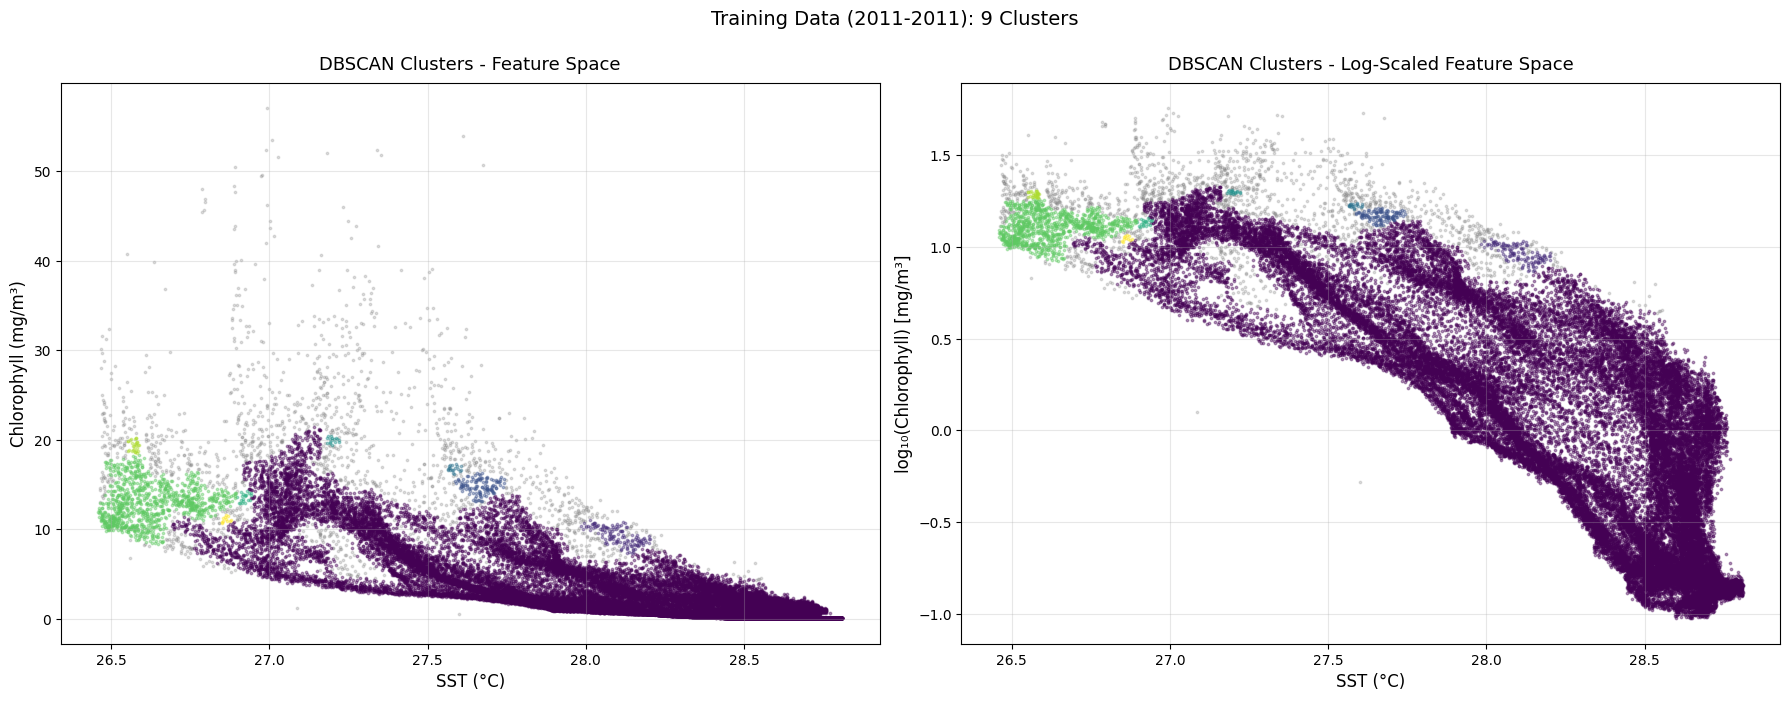

In [118]:
# Visualize feature space
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_map = {-1: '#808080'}
for i, cl in enumerate(cluster_labels_sorted):
    colors_map[cl] = palette[i]

# Left: Scaled features
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[0].scatter(training_sst[mask], training_chlor[mask], 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[0].set_xlabel('SST (°C)', fontsize=12)
axes[0].set_ylabel('Chlorophyll (mg/m³)', fontsize=12)
axes[0].set_title('DBSCAN Clusters - Feature Space', fontsize=13, pad=10)
axes[0].grid(True, alpha=0.3)
# axes[0].legend(loc='best', fontsize=9, markerscale=3)

# Right: Log-transformed chlorophyll
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[1].scatter(training_sst[mask], np.log10(training_chlor[mask]), 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[1].set_xlabel('SST (°C)', fontsize=12)
axes[1].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
axes[1].set_title('DBSCAN Clusters - Log-Scaled Feature Space', fontsize=13, pad=10)
axes[1].grid(True, alpha=0.3)
# axes[1].legend(loc='best', fontsize=9, markerscale=3)

plt.suptitle(f'Training Data ({training_years[0]}-{training_years[-1]}): {n_clusters} Clusters', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

In [119]:
# Print detailed cluster statistics
print("\n" + "=" * 80)
print("TRAINING DATA CLUSTER STATISTICS")
print("=" * 80)

for label in sorted(set(training_labels)):
    mask = training_labels == label
    sst_cluster = training_sst[mask]
    chlor_cluster = training_chlor[mask]
    
    if label == -1:
        print(f"\n⚪ Noise Points:")
    else:
        print(f"\n🔵 Cluster {label}:")
    
    print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
    print(f"  SST: {sst_cluster.mean():.2f} ± {sst_cluster.std():.2f} °C")
    print(f"       Range: [{sst_cluster.min():.2f}, {sst_cluster.max():.2f}] °C")
    print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
    print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")

print("\n" + "=" * 80)


TRAINING DATA CLUSTER STATISTICS

⚪ Noise Points:
  Pixels: 1,505 (3.4%)
  SST: 27.24 ± 0.47 °C
       Range: [26.46, 28.55] °C
  Chlorophyll: 18.549550 ± 8.538456 mg/m³
               Range: [0.521929, 56.999141] mg/m³

🔵 Cluster 0:
  Pixels: 41,811 (93.6%)
  SST: 28.22 ± 0.50 °C
       Range: [26.69, 28.81] °C
  Chlorophyll: 2.512408 ± 3.523436 mg/m³
               Range: [0.094471, 21.433119] mg/m³

🔵 Cluster 1:
  Pixels: 133 (0.3%)
  SST: 28.10 ± 0.05 °C
       Range: [27.98, 28.20] °C
  Chlorophyll: 9.295295 ± 0.925014 mg/m³
               Range: [7.364656, 11.081368] mg/m³

🔵 Cluster 2:
  Pixels: 119 (0.3%)
  SST: 27.67 ± 0.04 °C
       Range: [27.59, 27.74] °C
  Chlorophyll: 14.843435 ± 0.758471 mg/m³
               Range: [13.130376, 16.339874] mg/m³

🔵 Cluster 3:
  Pixels: 19 (0.0%)
  SST: 27.58 ± 0.01 °C
       Range: [27.56, 27.61] °C
  Chlorophyll: 16.812916 ± 0.294400 mg/m³
               Range: [16.186778, 17.321887] mg/m³

🔵 Cluster 4:
  Pixels: 16 (0.0%)
  SST: 27.20 ±

## 4. Apply Model to New Data

Select a time period to apply the trained clustering model.

In [120]:
# Configuration for new data
apply_year = 2009
apply_start = '2009-07-1'
apply_end = '2009-07-31'

sst_var = 'analysed_sst'
chlor_var = 'chlor_a'
chlor_group = 'geophysical_data'

sst_base_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
chlor_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-06-01_{year}-11-30"

print(f"Applying model to: {apply_start} to {apply_end}")

Applying model to: 2009-07-1 to 2009-07-31


In [121]:
# Load SST data for the period
print("\n" + "=" * 80)
print("LOADING SST DATA")
print("=" * 80)

sst_dir = sst_base_pattern.format(year=apply_year)
all_sst_files = sorted(glob.glob(os.path.join(sst_dir, '*.nc')))
print(f"  Total SST files in {apply_year}: {len(all_sst_files)}")

# Filter by date
sst_files = []
for sst_file in all_sst_files:
    try:
        with xr.open_dataset(sst_file) as ds:
            file_time = pd.to_datetime(ds.time.values[0])
            if pd.Timestamp(apply_start) <= file_time <= pd.Timestamp(apply_end):
                sst_files.append(sst_file)
    except:
        continue

print(f"  Files in period: {len(sst_files)}")

# Load datasets
sst_loader = L3DatasetLoader(variables=[sst_var], bbox=(lon_min, lon_max, lat_min, lat_max))
sst_datasets = sst_loader.load_multiple(sst_files)

# Process SST
sst_list = []
for ds in sst_datasets:
    sst_k = ds[sst_var].values.squeeze()
    sst_c = sst_k - 273.15
    sst_c[(sst_c < -2) | (sst_c > 35)] = np.nan
    sst_list.append(sst_c)

sst_mean = np.nanmean(np.stack(sst_list, axis=0), axis=0)
lat_sst = sst_datasets[0]['lat'].values
lon_sst = sst_datasets[0]['lon'].values

print(f"  SST range: {np.nanmin(sst_mean):.2f} to {np.nanmax(sst_mean):.2f} °C")
print(f"  Valid pixels: {np.sum(~np.isnan(sst_mean))}")


LOADING SST DATA
  Total SST files in 2009: 184
  Files in period: 30
  SST range: 28.15 to 30.42 °C
  Valid pixels: 137002


In [122]:
# Load chlorophyll data for the period
print("\n" + "=" * 80)
print("LOADING CHLOROPHYLL DATA")
print("=" * 80)

chlor_dir = chlor_base_pattern.format(year=apply_year)
all_chlor_files = glob.glob(os.path.join(chlor_dir, '**', '*.nc'), recursive=True)
print(f"  Total chlorophyll files in {apply_year}: {len(all_chlor_files)}")

# Filter by date (from filename)
chlor_files = []
for chlor_file in all_chlor_files:
    filename = os.path.basename(chlor_file)
    try:
        if 'AQUA_MODIS' in filename or 'MODIS' in filename:
            parts = filename.split('.')
            if len(parts) > 1:
                date_str = parts[1][:8]
                file_date = pd.to_datetime(date_str, format='%Y%m%d')
                if pd.Timestamp(apply_start) <= file_date <= pd.Timestamp(apply_end):
                    chlor_files.append(chlor_file)
    except:
        continue

print(f"  Files in period: {len(chlor_files)}")

if len(chlor_files) > 0:
    # Load datasets
    chlor_loader = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
    chlor_datasets = chlor_loader.load_multiple(chlor_files)
    
    # Extract data
    try:
        extractor = GPUDataExtractor(variables=[chlor_var])
        lon_chlor, lat_chlor, chlor_data = extractor.extract(chlor_datasets)
        chlor_flat = chlor_data[chlor_var]
        print(f"  GPU extraction: {len(chlor_flat)} points")
    except Exception as e:
        print(f"  GPU failed, using CPU...")
        all_lons, all_lats, all_chlor = [], [], []
        for ds in chlor_datasets:
            lat = ds['lat'].values.flatten()
            lon = ds['lon'].values.flatten()
            chlor = ds[chlor_var].values.flatten()
            valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & (chlor > 0))
            all_lats.extend(lat[valid])
            all_lons.extend(lon[valid])
            all_chlor.extend(chlor[valid])
        lat_chlor = np.array(all_lats)
        lon_chlor = np.array(all_lons)
        chlor_flat = np.array(all_chlor)
        print(f"  CPU extraction: {len(chlor_flat)} points")
else:
    print("  ⚠ No chlorophyll files found")
    chlor_flat = np.array([])
    lat_chlor = np.array([])
    lon_chlor = np.array([])


LOADING CHLOROPHYLL DATA
  Total chlorophyll files in 2009: 284
  Files in period: 50
  GPU extraction: 14552214 points


In [123]:
# Grid the data
print("\n" + "=" * 80)
print("GRIDDING DATA")
print("=" * 80)

# Bin chlorophyll
clip_mask = ((lon_chlor >= lon_min) & (lon_chlor <= lon_max) &
             (lat_chlor >= lat_min) & (lat_chlor <= lat_max))

chlor_binned, _, _, _ = binned_statistic_2d(
    lat_chlor[clip_mask], lon_chlor[clip_mask], chlor_flat[clip_mask],
    statistic='mean',
    bins=[lat_bins, lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]]
)

print(f"  Valid chlorophyll pixels: {np.sum(~np.isnan(chlor_binned))}")

# Interpolate SST
sst_interpolator = RegularGridInterpolator(
    (lat_sst, lon_sst), sst_mean,
    method='linear', bounds_error=False, fill_value=np.nan
)

lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)
points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
sst_regridded = sst_interpolator(points).reshape(chlor_binned.shape)

print(f"  Valid SST pixels: {np.sum(~np.isnan(sst_regridded))}")


GRIDDING DATA
  Valid chlorophyll pixels: 44164
  Valid SST pixels: 44898


In [124]:
# Apply clustering model
print("\n" + "=" * 80)
print("APPLYING CLUSTERING MODEL")
print("=" * 80)

valid_mask = ~np.isnan(sst_regridded) & ~np.isnan(chlor_binned)
n_valid = np.sum(valid_mask)
print(f"  Pixels with both SST and chlorophyll: {n_valid}")

if n_valid > 0:
    sst_valid = sst_regridded[valid_mask]
    chlor_valid = chlor_binned[valid_mask]
    
    # Create features
    features = np.column_stack([sst_valid, np.log10(chlor_valid)])
    features_scaled = scaler.transform(features)
    
    # Predict clusters
    labels = dbscan.fit_predict(features_scaled)
    
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    
    print(f"  Clusters found: {n_clusters_found}")
    print(f"  Noise points: {n_noise} ({100*n_noise/len(labels):.1f}%)")
    
    # Create cluster map
    cluster_map = np.full(sst_regridded.shape, np.nan)
    cluster_map[valid_mask] = labels
else:
    print("  ⚠ No valid data to cluster")
    labels = np.array([])
    cluster_map = np.full(sst_regridded.shape, np.nan)


APPLYING CLUSTERING MODEL
  Pixels with both SST and chlorophyll: 43721
  Clusters found: 1
  Noise points: 20 (0.0%)


## 5. Visualize Results

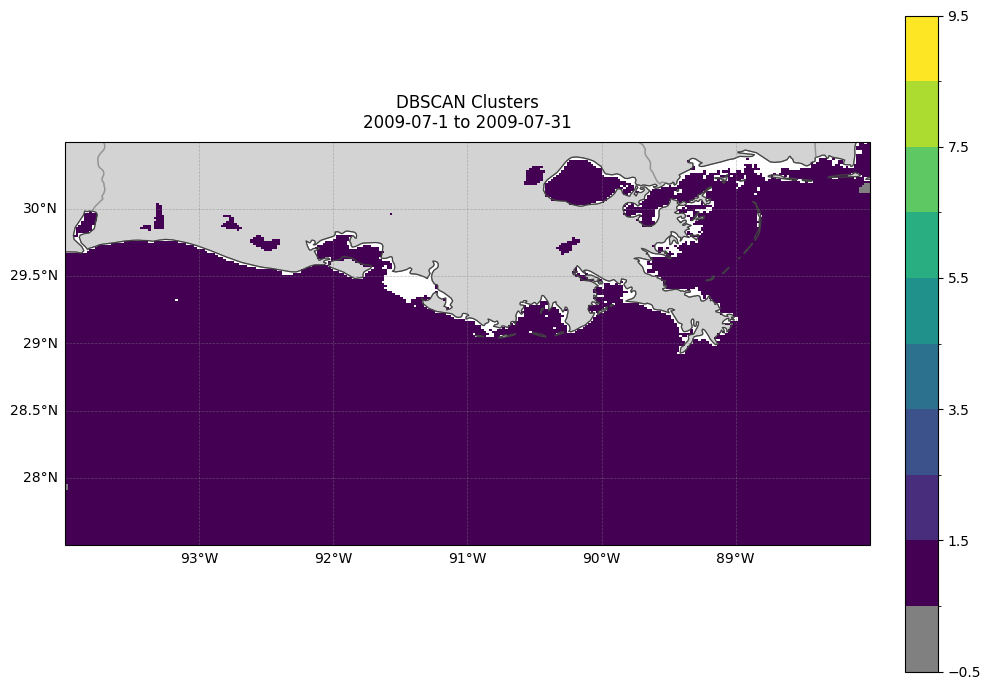

In [125]:
if n_valid > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), subplot_kw={'projection': ccrs.PlateCarree()})

    # Prepare plot data
    unique_labels_new = sorted(set(labels))
    cluster_labels_new = [l for l in unique_labels_new if l != -1]
    cluster_labels_sorted_new = sorted(cluster_labels_new)

    plot_map = np.full_like(cluster_map, np.nan)
    if len(cluster_labels_sorted_new) > 0:
        plot_map[valid_mask] = np.where(
            labels == -1, 0,
            np.array([cluster_labels_sorted_new.index(l) + 1 if l in cluster_labels_sorted_new else 0 
                      for l in labels])
        )

    # Cluster map only
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    cluster_plot = ax.pcolormesh(lon_edges, lat_edges, plot_map,
                                 cmap=cmap, norm=norm, shading='auto',
                                 transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = gl.right_labels = False

    plt.colorbar(cluster_plot, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'DBSCAN Clusters\n{apply_start} to {apply_end}', fontsize=12, pad=10)

    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")

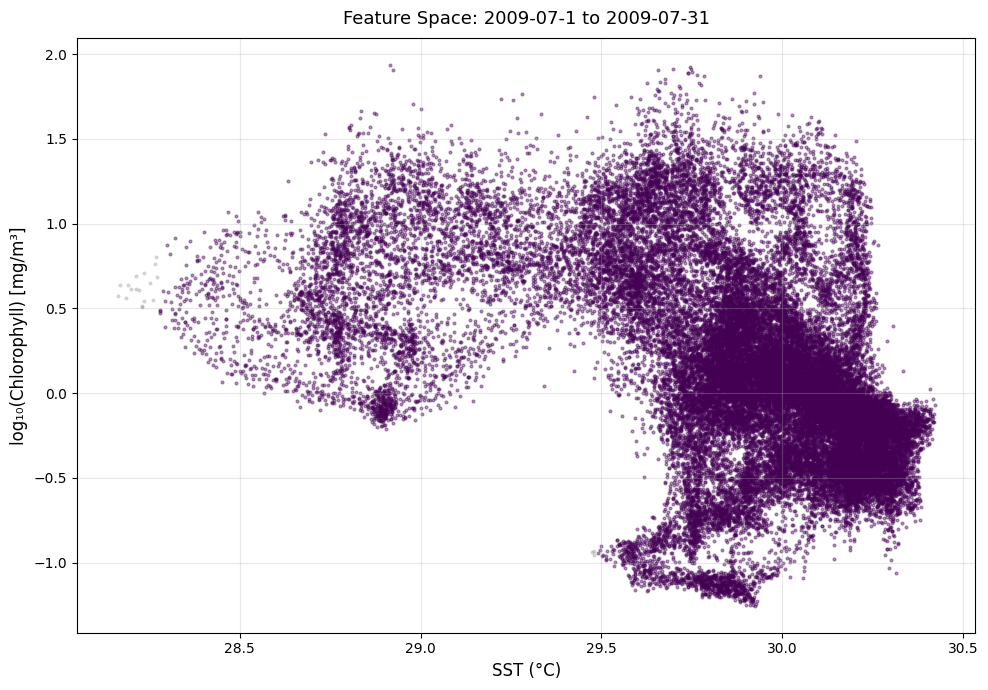

In [126]:
# Feature space for new data
if n_valid > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
        ax.scatter(sst_valid[mask], np.log10(chlor_valid[mask]), 
                   alpha=0.4 if cl != -1 else 0.25, s=4, color=color, label=label_text)
    
    ax.set_xlabel('SST (°C)', fontsize=12)
    ax.set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
    ax.set_title(f'Feature Space: {apply_start} to {apply_end}', fontsize=13, pad=10)
    ax.grid(True, alpha=0.3)
    # ax.legend(loc='best', fontsize=10, markerscale=2)
    
    plt.tight_layout()
    plt.show()

In [127]:
# Print cluster statistics for new data
if n_valid > 0:
    print("\n" + "=" * 80)
    print(f"CLUSTER STATISTICS: {apply_start.upper()} TO {apply_end.upper()}")
    print("=" * 80)
    
    for label in sorted(set(labels)):
        mask = labels == label
        sst_cluster = sst_valid[mask]
        chlor_cluster = chlor_valid[mask]
        
        if label == -1:
            print(f"\n⚪ Noise Points:")
        else:
            print(f"\n🔵 Cluster {label}:")
        
        print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
        print(f"  SST: {sst_cluster.mean():.2f} ± {sst_cluster.std():.2f} °C")
        print(f"       Range: [{sst_cluster.min():.2f}, {sst_cluster.max():.2f}] °C")
        print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
        print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")
    
    print("\n" + "=" * 80)


CLUSTER STATISTICS: 2009-07-1 TO 2009-07-31

⚪ Noise Points:
  Pixels: 20 (0.0%)
  SST: 28.41 ± 0.45 °C
       Range: [28.16, 29.48] °C
  Chlorophyll: 3.685260 ± 1.687913 mg/m³
               Range: [0.110392, 6.354063] mg/m³

🔵 Cluster 0:
  Pixels: 43,701 (100.0%)
  SST: 29.86 ± 0.40 °C
       Range: [28.28, 30.42] °C
  Chlorophyll: 3.390256 ± 5.784424 mg/m³
               Range: [0.055742, 86.311951] mg/m³



## 6. Summary

The trained DBSCAN model can identify oceanic regimes based on SST and chlorophyll patterns. The model was trained on 2005-2011 data and can be applied to any new time period with SST and chlorophyll measurements.

**Next Steps:**
- Apply to different time periods
- Compare cluster distributions across seasons/years
- Analyze environmental drivers of each cluster
- Export cluster masks for further analysis